# Notebook 1 — The recording

*SWC ENC 2026 · ephys-pop module*

Before we can *sort* spikes we need to know exactly what a recording **is**. This
notebook builds the forward model the rest of the day inverts: a probe with
channels at known positions, neurons with known waveforms and spike times, and the
voltage that results. Because we choose the ground truth, every later stage can be
graded against it.

**In this notebook you will:**
1. Build a **probe** and see that a spike lands on several channels at once.
2. Read a unit's **footprint** and locate it on the probe.
3. Generate a full **recording** and find the true spikes buried in it.
4. **Recover a clean waveform** from noisy data by averaging — a preview of the
   whole pipeline's logic.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

## 1. The probe

A Neuropixels probe is a thin shank studded with hundreds of recording sites. We
use a simpler stand-in: a **single column** of `n_channels` sites stacked
vertically, `pitch` micrometres apart. The only thing that matters is that channels
have **positions** — so a spike near one site also shows up, more weakly, on its
neighbours.

32 channels spanning 0–620 µm


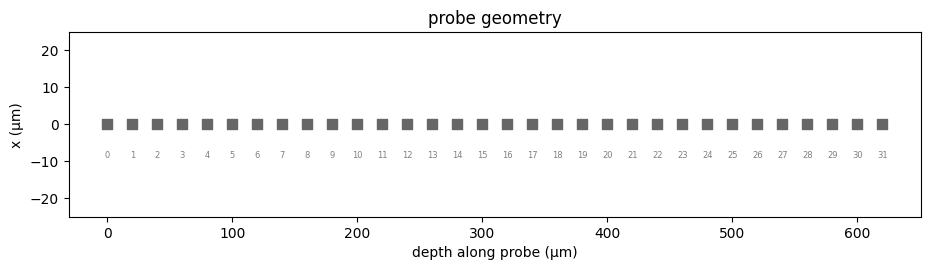

In [2]:
probe = ps.make_probe(n_channels=32, pitch=20.0)
print(f"{probe.n_channels} channels spanning {probe.y.min():.0f}–{probe.y.max():.0f} µm")

# Drawn sideways: depth runs left-to-right, channel 0 (top of probe) at the left.
ps.plotting.plot_probe(probe)
plt.show()

## 2. A unit and its template

A single neuron shows up as a **template**: its stereotyped spike shape, spread
across channels. We build one from two pieces — a **temporal waveform** (the
canonical biphasic extracellular spike: a sharp negative trough, then a slower
positive rebound) and a **spatial footprint** (amplitude falls off with distance
from the cell body). Their product is the spatiotemporal template.

template shape (channels, samples): (32, 61)


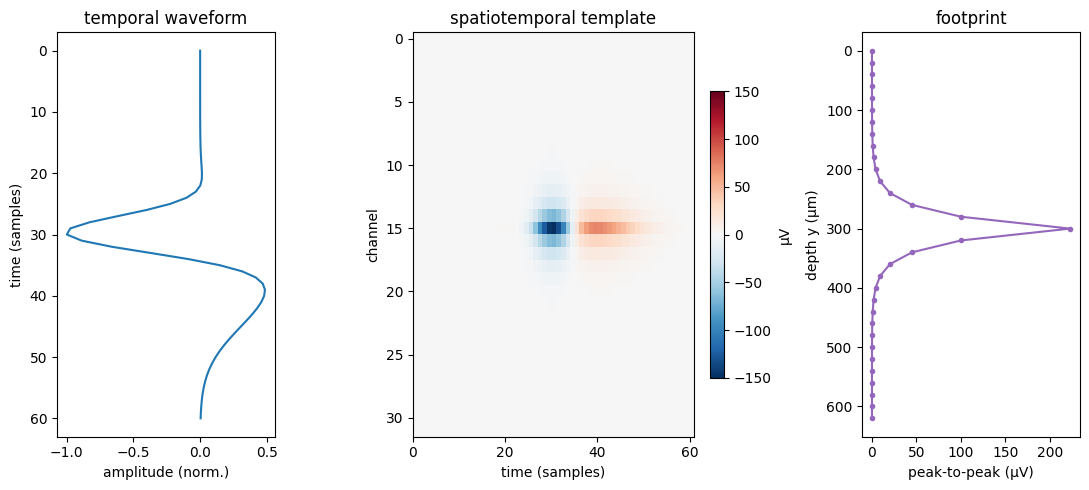

In [3]:
# Place a unit at depth 300 µm with a 150 µV peak amplitude.
unit_xy = np.array([0.0, 300.0])
waveform = ps.spike_waveform()
template = ps.make_template(probe, unit_xy, amplitude=150.0, waveform=waveform)
print("template shape (channels, samples):", template.shape)

fig, axes = plt.subplots(1, 3, figsize=(11, 5), width_ratios=[1.4, 2, 1.4])
axes[0].plot(waveform, np.arange(len(waveform)))
axes[0].set_title("temporal waveform"); axes[0].set_xlabel("amplitude (norm.)")
axes[0].set_ylabel("time (samples)"); axes[0].invert_yaxis()
ps.plotting.plot_template(template, probe, ax=axes[1])
ps.plotting.plot_footprint(template, probe, ax=axes[2])
plt.tight_layout(); plt.show()

The spike is biggest on the channels nearest the cell and fades away above and
below — that spatial spread is both a blessing (it lets us *localise* the unit) and
a curse (nearby units overlap). The **peak-to-peak amplitude** per channel is the
footprint; the channel where it's largest is the unit's **peak channel**.

**Exercise 1** *(~4 min · easy)*. Complete `footprint` (peak-to-peak per channel) and
`peak_channel` (the channel with the biggest footprint). The peak channel should be
the one physically nearest the unit's true depth.

> **Check / unstuck.** The unit is at 300 µm with 20 µm pitch, so expect peak
> **channel 15** (≈ 300/20). Stuck? Use `ps.footprint(template)` and
> `ps.peak_channel(template)`.

In [4]:
def footprint(template):
    return template.max(axis=1) - template.min(axis=1)

def peak_channel(template):
    return int(np.argmax(footprint(template)))

pc = peak_channel(template)
print(f"peak channel: {pc}  (at depth {probe.y[pc]:.0f} µm; unit truly at {unit_xy[1]:.0f} µm)")

peak channel: 15  (at depth 300 µm; unit truly at 300 µm)


## 3. A full recording

Now the real thing. `make_recording` scatters several units at random depths, draws
a **Poisson spike train** for each — spikes fired at random times at some average
rate per second, the simplest stand-in for a real neuron's firing — and superposes
their templates into the traces. Then it buries them in two kinds of background noise,
both of which Notebook 2 is devoted to cleaning up:

- **spatially correlated noise.** "Correlated" means "tends to move together";
  "spatially" means "between nearby channels." Neighbouring sites sit in the same
  patch of tissue and pick up overlapping electrical fields from far-off sources, so
  when one channel's noise swings up its neighbours tend to swing up too. (Notebook 2
  makes this precise and removes it.)
- a slow **common-mode** fluctuation: a drifting signal shared by *every* channel at
  once, like the tissue's local field potential.

Finally it hands back the traces *and* the **ground truth** — every spike time, label,
and template, the answers a real recording never gives you.

<details>
<summary><b>▸ Go deeper: the generative model the whole pipeline inverts (optional)</b></summary>

Every stage of this module is undoing one equation. The recorded voltage on channel
$c$ at time $t$ is a **linear superposition** of all neurons' spikes plus noise:

$$V_c(t) \;=\; \sum_{j}\ \sum_{s \in \text{spikes of unit } j} W_{j,c}(t - t_s)\ \;+\; \eta_c(t),$$

where $W_{j,c}$ is unit $j$'s template on channel $c$ (a spatial footprint × a
temporal waveform), $t_s$ are its spike times (a Poisson process), and $\eta$ is the
noise. Reading it left to right is the *forward* model — what we just built. Spike
sorting reads it **right to left**: given only $V$, recover the unit count, the
templates $W_j$, and every spike time $t_s$.

That framing tells you exactly what each later notebook is for. The noise $\eta$ is
spatially correlated → **whiten** it (NB2). The $t_s$ are sparse threshold-crossing
events → **detect** them (NB3). The templates $W_j$ are unknown → **cluster** similar
spikes and average them (NB4–5). And because the model is a *sum*, overlapping spikes
add linearly → they can be pulled apart by fitting the templates back, one at a time
(**matching pursuit**, NB6). Because it's synthetic, we know every term on the right,
so we can grade the inversion exactly (NB8).
</details>

In [5]:
rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
gt = rec.ground_truth

### The two objects you'll work with

Almost everything in this module comes out of these two objects, so it's worth a
moment to see what's inside them — you'll reach into them in the exercises.

**`rec`** — a `Recording`, the data you'd have from a real probe:

| attribute | what it is |
|---|---|
| `rec.traces` | the voltage: a `(n_samples, n_channels)` array |
| `rec.fs` | the sampling rate (samples per second) |
| `rec.probe` | the `Probe` from section 1 — `rec.probe.y` holds the channel depths |
| `rec.duration_s` | the length of the recording, in seconds |

**`gt = rec.ground_truth`** — a `GroundTruth`, the answers (a real recording never
gives you these; we use them only to build intuition now and to *grade* the sort at
the end):

| attribute | what it is |
|---|---|
| `gt.spike_times` | the sample index of every spike, all units pooled together |
| `gt.spike_labels` | which unit fired each of those spikes |
| `gt.templates` | each unit's template: `(n_units, n_channels, n_samples)` |
| `gt.unit_xy`, `gt.unit_amplitude` | each unit's position and peak amplitude |

The key idiom you'll use often: **the spike times of one unit** are
`gt.spike_times[gt.spike_labels == unit]`. Let's peek at a few values:

In [6]:
print(f"rec.traces: {rec.traces.shape}   rec.fs: {rec.fs/1e3:.0f} kHz   duration: {rec.duration_s:.0f} s")
print(f"ground truth: {gt.n_units} units, {len(gt.spike_times)} spikes total")
print("first 5 spike times :", gt.spike_times[:5])
print("first 5 spike labels:", gt.spike_labels[:5], "(the unit that fired each)")
print("spikes per unit     :", np.bincount(gt.spike_labels))
print("true unit depths (µm):", np.round(np.sort(gt.unit_xy[:, 1])).astype(int))

# the idiom in action: pull unit 0's spike times
unit0_times = gt.spike_times[gt.spike_labels == 0]
print(f"\nunit 0 fired {len(unit0_times)} times; first few at samples {unit0_times[:3]}")

rec.traces: (600000, 32)   rec.fs: 30 kHz   duration: 20 s
ground truth: 6 units, 401 spikes total
first 5 spike times : [3244 3874 4851 6002 8445]
first 5 spike labels: [5 3 2 2 5] (the unit that fired each)
spikes per unit     : [66 91 87 51 65 41]
true unit depths (µm): [ 91 165 244 333 459 554]

unit 0 fired 66 times; first few at samples [29154 29185 29926]


Zoom in on a single spike from one unit, on the band of channels around it. The red
line is the true spike time. Notice the two things that make sorting hard: a single
spike appears on a *band* of neighbouring channels (so the same event must not be
counted on each channel separately), and its amplitude peaks on the channel nearest
the cell and fades away — the footprint from section 2, now buried in noise.

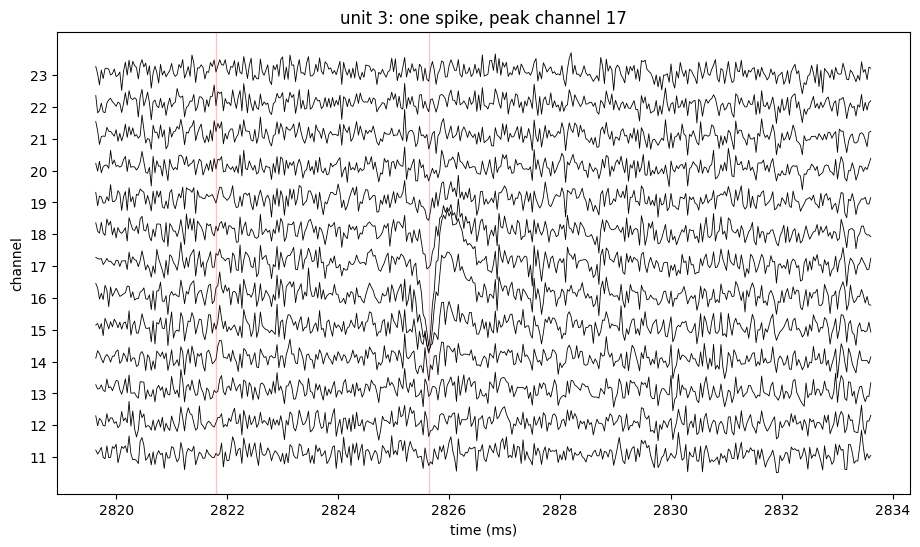

In [7]:
# Center on one spike of the largest-amplitude unit and show its channel band.
big_unit = int(np.argmax(gt.unit_amplitude))
ps.plotting.plot_unit_spike(rec, unit=big_unit, which=5, n_channels=13)
plt.show()

That's one spike seen clearly. The catch is that the *whole* recording — every
channel, all 20 seconds — is a dense wall of these events layered on noise, and
sometimes two spikes land almost on top of each other so their waveforms **add**
(the problem matching pursuit solves in Notebook 6). Here's a wider window across a
band of channels to give a feel for the density:

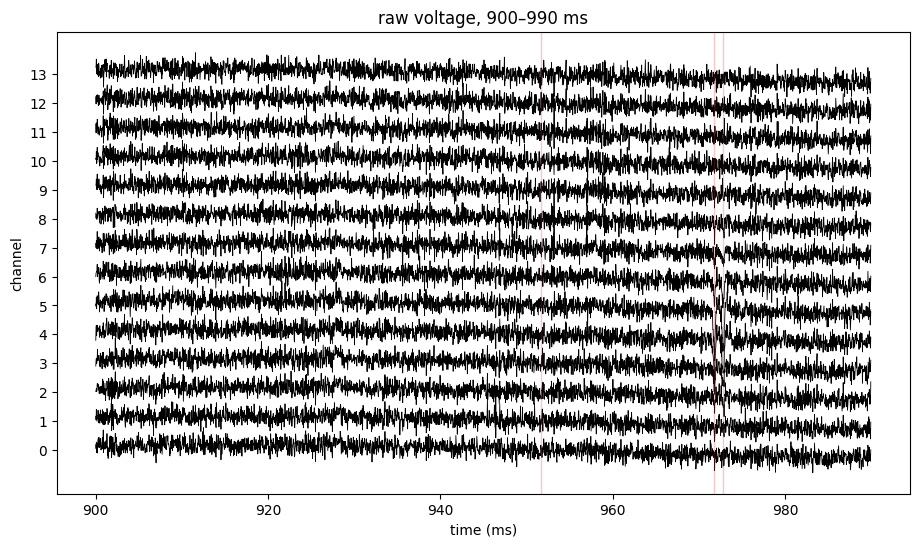

In [8]:
ps.plotting.plot_traces(rec, channels=range(0, 14), t0=0.90, t1=0.99,
                        mark_spikes=gt.spike_times)
plt.show()

## 4. Recover a clean waveform by averaging

Here's the whole module's logic in miniature. A single spike is deep in the noise,
but the ground truth tells us *when* every spike of a given unit fired. If we cut a
short **snippet** around each of that unit's spike times and **average** them, the
noise (which is random) cancels and the waveform (which repeats) survives. This is
exactly how, later, we'll turn a *cluster* of detected spikes into a template — the
only difference is that here the spike times are handed to us.

**Exercise 2** *(~7 min · meaty)*. Complete `average_waveform`: for a given unit and
channel, cut a `2*half+1`-sample snippet around each ground-truth spike time and
return the average. We'll overlay it on the unit's true template row.

> **Check / unstuck.** The recovered waveform should sit almost on top of the true
> template (a clean biphasic spike), despite the raw single snippets being noisy.
> Stuck? Use `ps.average_waveform(rec, unit, channel)`.

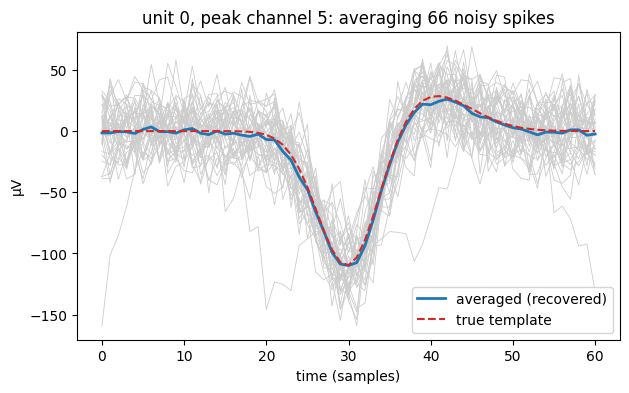

In [9]:
def average_waveform(rec, unit, channel, half=30):
    gt = rec.ground_truth
    times = gt.spike_times[gt.spike_labels == unit]
    snippets = np.array([rec.traces[t - half:t + half + 1, channel] for t in times])
    return snippets.mean(axis=0), snippets

unit = 0
pc = int(np.argmax(gt.templates[unit].max(1) - gt.templates[unit].min(1)))
avg, snippets = average_waveform(rec, unit, pc)

plt.figure(figsize=(7, 4))
for s in snippets[:40]:
    plt.plot(s, color="0.8", lw=0.6)
plt.plot(avg, color="tab:blue", lw=2, label="averaged (recovered)")
plt.plot(gt.templates[unit][pc], color="tab:red", lw=1.5, ls="--", label="true template")
plt.title(f"unit {unit}, peak channel {pc}: averaging {len(snippets)} noisy spikes")
plt.xlabel("time (samples)"); plt.ylabel("µV"); plt.legend()
plt.show()

The single snippets (grey) are a mess; their average (blue) lands right on the true
template (red). That's the engine underneath everything: **noise averages away,
signal doesn't.** The catch is that on a real recording nobody hands you the spike
times or the labels — you have to *find* the spikes and *group* them yourself. That's
the rest of the module.

## Wrap-up

You built the forward model: a probe, spatiotemporal templates, Poisson spike
trains, and noisy traces — plus the ground truth to grade against. You saw a spike
spread across channels, located a unit from its footprint, and recovered a clean
waveform by averaging aligned snippets.

**Next (Notebook 2 — preprocessing):** before detecting anything, we clean the
traces — high-pass filter out the slow common-mode drift, then **whiten** away the
spatial noise correlations so a detection threshold means the same thing on every
channel.